In [1]:
from multiprocessing import Pool
import subprocess
import yaml
import os
import sys
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import tempfile
import copy
from datetime import datetime
import pandas as pd
from collections import Counter
import numpy as np
import threading
source_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(source_path)

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from joblib import load
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import cv2

In [ ]:
selected_FE ='clip-vit-large-patch14'#'trocr-base-stage1'# 'clip-vit-large-patch14'#'DeiT-Tiny' #'resnet18'#'clip-vit-large-patch14'  # Example feature extractor, can be changed
input_dir=source_path+f'\\outputs\\online_deep_feature_extraction\\{selected_FE}\\representation_extraction\\extracted_representation'
use_test_private = False
data_augmentation = False
suffix = '_augmented' if data_augmentation else ''
kind = 'patches_224'  # Example kind, can be changed
train_filename,val_filename, test_filename = file_IO.load_input_files(source_path,selected_FE,kind,suffix)
mean,scale = model_utils.get_normalization_parameters(train_filename)
test_private = file_IO.load_preprocessed_files(kind, 'test')

use_external_validation = True
if use_external_validation:
    validation_mode = 'val_only'  # 'kfold_train_only', 'val_only', '1fold_train_only'
else:
    validation_mode = '1fold_train_only'  # 'kfold_train_only', 'val_only', '1fold_train_only'
#see from training logs ad set by hand
extra_view=False
extra_integration_mode = 'concat'  # 'concat' or 'add'
aggregation_mode = None #'mean'  # 'mean' or 'max'
if extra_view:
    extra_train_filename, extra_val_filename = file_IO.load_input_files(source_path,selected_FE,kind='body',suffix='')
else:
    extra_train_filename, extra_val_filename = None, None

list_of_metrics = ['majority_vote', 'weighted_vote', 'most_probable']
selected_metric='weighted_vote'
if kind == 'body':
    selected_metric = 'most_probable'  # Use the metric you want to analyze

In [ ]:
evaluation_mode = 'backbone_only' #full_model
calibrate=False
threshold=0.5

head_type = 'pytorch'  # 'sklearn' or 'pytorch' or none
selected_classification_head = 'MLPClassifier1'#'MLPClassifier1'#'TransformerClassifier'#'1DCNNClassifier'#'MLPClassifier2'
model_parameters = {
    'n_neurons':128,
    #'hidden_sizes': [256,128, 64],  # Hidden sizes for MLPClassifier2
    'dropout':0.4,
    'with_input_norm': 'batch_norm',  # Whether to use input normalization 'batch_norm' , None
    'mean': mean,  # Mean for input normalization
    'scale': scale,  # Scale for input normalization
}
if evaluation_mode == 'backbone_only':
    classification_head, val_df = data_loading.load_classification_head(selected_FE,selected_classification_head,head_type,
                                                                    validation_mode,train_filename, source_path,**model_parameters)
    if use_external_validation:
        if use_test_private:
            val_df = pd.read_csv(test_filename)
        else:
            val_df = pd.read_csv(val_filename) 
        val_df['train'] = 0  # Mark validation data
    if extra_view:
        val_df_extra = pd.read_csv(extra_val_filename)
        if not(use_external_validation):
            _, val_df_extra = data_loading.load_classification_head(selected_FE,selected_classification_head,head_type,
                                                                    validation_mode,extra_train_filename,source_path)
        val_df = dataframes.merge_dfs(val_df, val_df_extra, mode=extra_integration_mode)
    val_df = dataframes.aggregate_dfs(val_df,mode=aggregation_mode)

    # Keep only 5 patches per page
    #val_df_test = val_df.groupby('page').head(40).reset_index(drop=True)

    #res_df=evaluation_utils.compute_predictions_and_uncertainties(classification_head, val_df, head_type,calibrate=True,threshold=0.5)
    res_df=evaluation_utils.compute_predictions_and_uncertainties(classification_head, val_df, head_type,calibrate=calibrate,threshold=threshold)

In [ ]:
custom_pretrained = 'progressive'  # 'original', 'contrastive', 'fine-tune'
contrastive_mode = False
num_workers = 4
pin_memory = True
if evaluation_mode == 'full_model':
    use_external_validation = True #I don't need to check if use_external validation, I assume external validation true with these models 
    load_data_from = 'pre-processed' #'zarr', 'folder'
    transform = u_transforms.get_transform(selected_model, use_patches=True, custom=custom_transform, mode=transform_mode)
    backbone = model_utils.get_model(name=selected_model, mode=model_mode, pretrained=pretrained, truncation=truncation, 
                                    contrastive=contrastive_mode,custom_pretrained=custom_pretrained)
    out=model_utils.test_output(224,transform, backbone,huggingface=huggingface)
    in_features = out.shape[1]
    print(f"Model {selected_model} output features: {in_features}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device is: ",device)
    model = model.to(device)

    if contrastive_mode:
        model = backbone
    else:
        classificaton_head = model_utils.get_classification_head(selected_classifier,in_features)
        model = model_utils.JoinedModels(backbone, classificaton_head)

    if use_test_private: 
        val_filename = file_IO.load_preprocessed_files(kind, 'test')
        zarr_path_val = "C:\\Users\\andre\PhD\Datasets\ICDAR 2013 - Gender Identification Competition Dataset\\private_writers.zarr"
    else:
        val_filename = file_IO.load_preprocessed_files(kind, 'val')
        zarr_path_val = "C:\\Users\\andre\PhD\Datasets\ICDAR 2013 - Gender Identification Competition Dataset\\public_writers.zarr"
    
    val_df = pd.read_csv(f"{source_path}\\outputs\\preprocessed_data\\{val_filename}")
    val_df=file_IO.change_filename_from_to(val_df, fr=saved, to=running)
    val_df['page'] = val_df.groupby(['writer', 'isEng', 'same_text']).ngroup()

    if load_data_from == 'zarr':
        val_dataset = ZarrImageCropDataset_resize(val_df, zarr_path_val, transform=transform, 
                                                    huggingface=huggingface, use_augmentation=False)
    elif load_data_from == 'pre-processed':
        val_dataset = PreProcessedDataset(val_df, 'male' ,transform=transform, 
                                            huggingface=huggingface, use_augmentation=False)
    
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers,pin_memory=pin_memory)

    model.eval()
    y_prob = []
    for i, batch in enumerate(val_dataloader):
        logits = model_utils.compute_output_gpu(model, device, batch)
        probs = F.softmax(logits, dim=1)  # shape: [N, 2]
        y_prob.append(probs[:, 1].cpu().numpy())  # probability of class 1
        if i == 0:
            start_time = time.time()
        else:
            elapsed = time.time() - start_time
            images_processed = len(y_prob)
            print(f'''Elapsed time {elapsed:.2f};Processed batch {i} out of {len(val_dataloader)}; Speed: {images_processed / elapsed:.2f} images/sec; 
                Projected time: {(len(val_dataloader) - i) * (elapsed / (i+1)):.2f} seconds''')

    res_df=evaluation_utils.compute_predictions_and_uncertainties(classification_head, val_df, head_type,
                                                                  calibrate=calibrate,threshold=threshold,use_external_probs=y_prob)

In [ ]:
args = script_launching.DotDict(
        data_augmentation=data_augmentation,
        use_external_validation=use_external_validation,
        validation_mode=validation_mode,
        selected_classification_head=selected_classification_head,
        selected_FE=selected_FE,
        head_type=head_type,
        extra_view=extra_view,
        extra_integration_mode=extra_integration_mode,
        aggregation_mode=aggregation_mode,
        train_filename=train_filename,
        val_filename=val_filename,
        extra_train_filename=extra_train_filename,
        extra_val_filename=extra_val_filename,
        selected_metric=selected_metric,
        evaluation_mode = evaluation_mode,
        calibrate=calibrate,
        threshold=threshold,
        custom_pretrained = custom_pretrained,
        num_workers=num_workers,
        pin_memory=pin_memory,
        #script_mode='standalone'
    )
'''print(val_df['writer'].nunique(), 'unique writers')
print(len(val_df)/val_df['page'].nunique(), 'samples per writer')
cols_to_drop = [c for c in val_df.columns if c.startswith('f') and len(c) > 1 and c[1].isdigit()]
print(len(cols_to_drop), 'columns to drop')
#deit 192
#resnet18 512
#resnet50 2048
#clipvit-large-patch14 768
print([c for c in val_df.columns if not(c.startswith('f') and len(c) > 1 and c[1].isdigit())])
#val_df.drop(columns=cols_to_drop[256:], inplace=True, errors='ignore')
#print(len(val_df.columns), 'columns after drop')'''

#clip-vit
#best acc model: 0.7676056338028169, 0.703
#best val_loss model: 0.7676056338028169, 0.700
#sklearn model:  0.68, 0.79
#torch model with input batch norm: 0.78, 0.69
#128, 0.4, 1e-4, adamW, gradnorm, batch_nomr -> 0.71, 0.785 on val |  -> 0.68 on individual, 0.738 weighted ensembled
#256, 0.4, 1e-5, adamW, gradnorm, batch_nomr -> 0.707, 0.764 on val |  -> 0.684 on individual, 0.754 weighted ensembled
#deit-tiny
#128, 0.4, 1e-3, adamW, gradnorm, batch_nomr -> 0.680, 0.718 on val |  -> 0.689 on individual, 0.787 weighted ensembled
###-------------------------------------###
#resnet50
#512, 0.2, 1e-4, adamW, no gradnorm, batch_norm -> 0.673, 0.725 | 0.633, 0.656
#resnet18
#128, 0.4, 1e-4, adamW, no gradnorm, batch_norm -> 0.661, 0.725 | 0.663, 0.736

71 unique writers
40.0 samples per writer
768 columns to drop
['writer', 'isEng', 'same_text', 'file_name', 'male', 'Usage', 'x', 'y', 'x2', 'y2', 'n_cc', 'black_ratio', 'index', 'page', 'train']


## sub-accuracy on wrong and correct pages

In [112]:
failed=res_df[res_df['weighted_vote']!= res_df['grouped_true']]
correct = res_df[res_df['weighted_vote'] == res_df['grouped_true']]
print("Failed predictions:", len(failed))
print("Correct predictions:", len(correct))

Failed predictions: 3200
Correct predictions: 8160


In [113]:
failed_pages = failed['page'].unique()
print("5 unique pages from failed:", failed_pages[:5])
print("Failed predictions:", len(failed_pages))
print("Correct predictions:", len(correct['page'].unique()))

5 unique pages from failed: [ 8  9 10 11 16]
Failed predictions: 80
Correct predictions: 204


In [114]:
display(failed[failed['page'] == 16][[selected_metric,selected_metric+'_uncertainty', 'grouped_true', 'y_prob', 'y_pred']].sort_values(by='y_prob', ascending=False))

,weighted_vote,weighted_vote_uncertainty,grouped_true,y_prob,y_pred
640,1,0.374936,0,0.779426,1
644,1,0.374936,0,0.772894,1
654,1,0.374936,0,0.733128,1
679,1,0.374936,0,0.727410,1
649,1,0.374936,0,0.710611,1
650,1,0.374936,0,0.704320,1
657,1,0.374936,0,0.684134,1
668,1,0.374936,0,0.682907,1
675,1,0.374936,0,0.677251,1
646,1,0.374936,0,0.670950,1


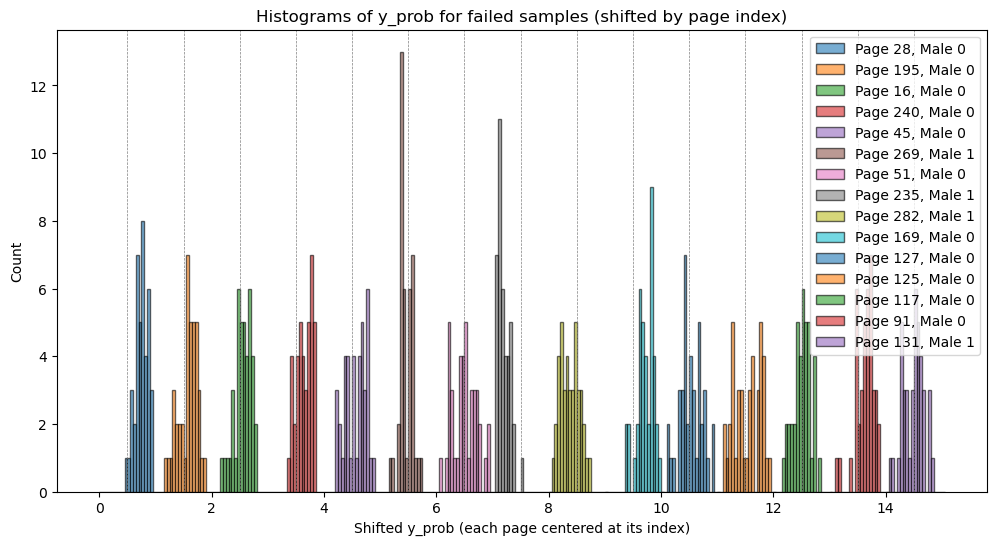

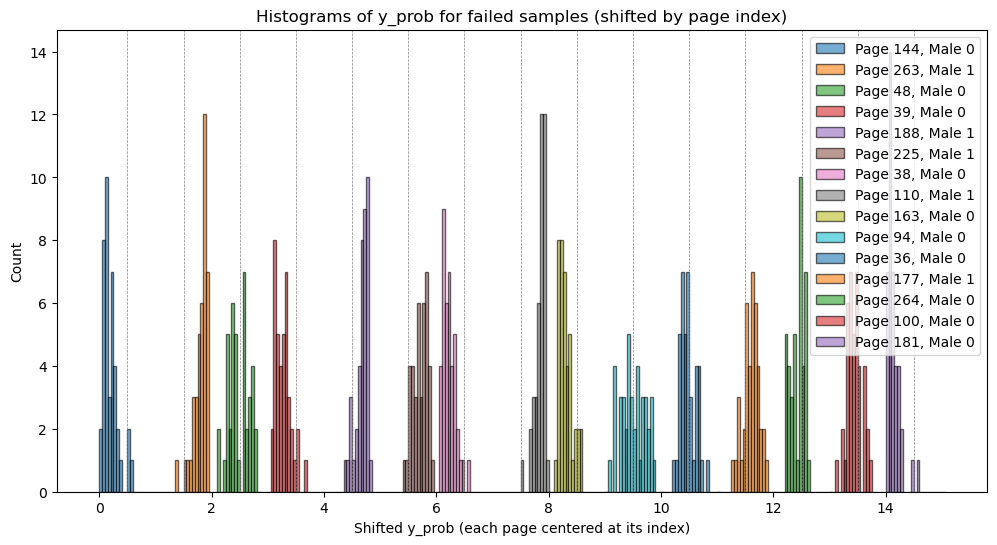

In [115]:
def display_pred_distribution(failed, failed_pages):
    plt.figure(figsize=(12, 6))
    bin_width = 0.05
    np.random.shuffle(failed_pages)
    for i, page in enumerate(failed_pages[:15]):
        subset = failed[failed['page'] == page]['y_prob']
        isMale = failed[failed['page'] == page]['grouped_true'].iloc[0]
        # Shift the histogram center by page number (e.g., offset by i)
        shifted = subset + i
        plt.hist(shifted, bins=np.arange(i, i + 1 + bin_width, bin_width), alpha=0.6, edgecolor='black', label=f'Page {page}, Male {isMale}')
        # Mark the center for each page
        plt.axvline(i + 0.5, color='gray', linestyle='--', linewidth=0.5)

    plt.title('Histograms of y_prob for failed samples (shifted by page index)')
    plt.xlabel('Shifted y_prob (each page centered at its index)')
    plt.ylabel('Count')
    plt.legend()
    plt.show()
display_pred_distribution(failed, failed_pages)
display_pred_distribution(correct, correct['page'].unique())

In [116]:
print('accuracy on failed',len(failed[failed['male']==failed['y_pred']])/len(failed))
print('accuracy on correct',len(correct[correct['male']==correct['y_pred']])/len(correct))

accuracy on failed 0.3040625
accuracy on correct 0.8286764705882353


In [117]:
cols_to_drop = [c for c in res_df.columns if not(c.startswith('f') and len(c) > 1 and c[1].isdigit())]
print(f"Columns to drop: {cols_to_drop}")

Columns to drop: ['writer', 'isEng', 'same_text', 'file_name', 'male', 'Usage', 'x', 'y', 'x2', 'y2', 'n_cc', 'black_ratio', 'index', 'page', 'train', 'y_prob', 'y_pred', 'grouped_true', 'majority_vote', 'majority_vote_uncertainty', 'weighted_vote', 'weighted_vote_uncertainty', 'most_probable', 'most_probable_uncertainty']


In [118]:
c_of_interest=['page','male','y_pred','y_prob','grouped_true','weighted_vote','majority_vote','weighted_vote_uncertainty']
test = res_df[c_of_interest].copy()
display(test[test['page'] == 60])

,page,male,y_pred,y_prob,grouped_true,weighted_vote,majority_vote,weighted_vote_uncertainty
2400,60,0,1,0.549330,0,0,0,0.845139
2401,60,0,0,0.356039,0,0,0,0.845139
2402,60,0,0,0.269255,0,0,0,0.845139
2403,60,0,0,0.208013,0,0,0,0.845139
2404,60,0,0,0.283204,0,0,0,0.845139
2405,60,0,0,0.188167,0,0,0,0.845139
2406,60,0,0,0.307862,0,0,0,0.845139
2407,60,0,0,0.276982,0,0,0,0.845139
2408,60,0,0,0.276556,0,0,0,0.845139
2409,60,0,0,0.292474,0,0,0,0.845139


## descriptive statistics

count    11360.000000
mean         0.429039
std          0.240269
min          0.000236
25%          0.237762
50%          0.420159
75%          0.615852
max          0.983159
Name: y_prob, dtype: float64

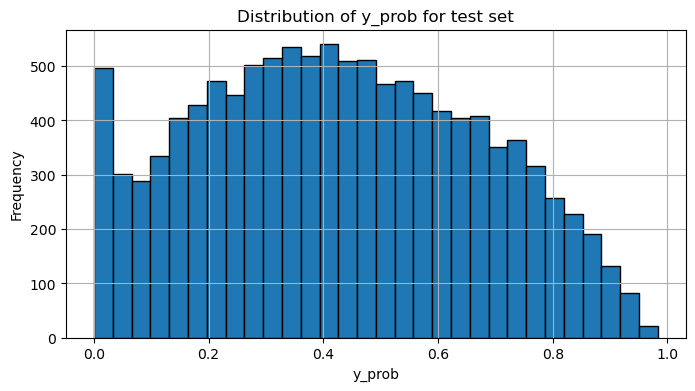

In [119]:
#probability distribution
display(res_df[res_df['train']==0]['y_prob'].describe())
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
res_df[res_df['train']==0]['y_prob'].hist(bins=30, edgecolor='black')
plt.title('Distribution of y_prob for test set')
plt.xlabel('y_prob')
plt.ylabel('Frequency')
plt.show()

In [120]:
#descriptive statistics for uncertainty
res_df[res_df['train']==0][[metric+'_uncertainty' for metric in list_of_metrics]].describe()

,majority_vote_uncertainty,weighted_vote_uncertainty,most_probable_uncertainty
count,11360.000000,11360.000000,11360.000000
mean,0.469894,0.684510,0.805678
std,0.325948,0.313700,0.118490
min,0.000000,0.005751,0.378086
25%,0.150000,0.451191,0.721944
50%,0.500000,0.788998,0.816371
75%,0.800000,0.962914,0.892661
max,0.950000,1.000000,0.999528


In [121]:

print(len(res_df[(res_df['train']==0) & (res_df['male']==0)])/len(res_df[res_df['train']==0]))

0.6056338028169014


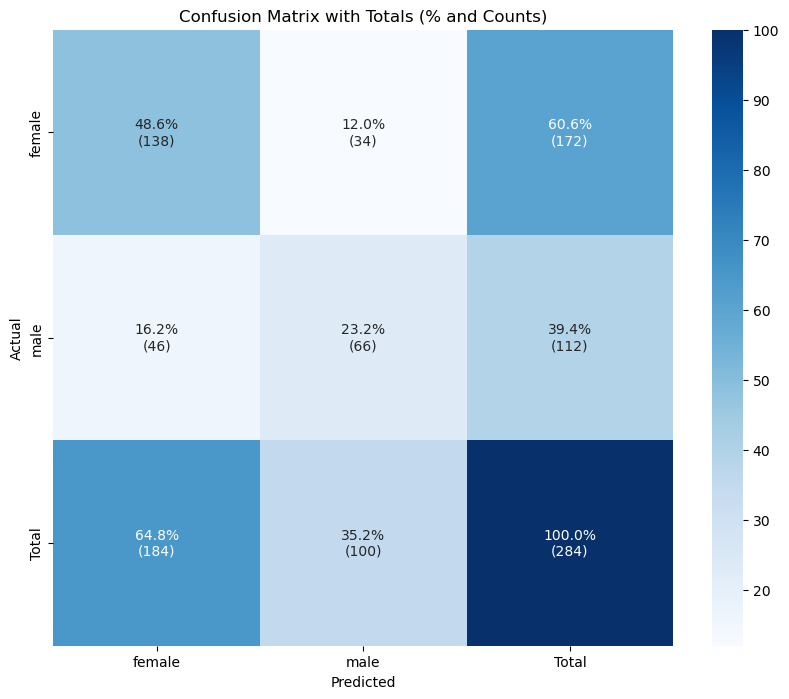

              precision    recall  f1-score   support

      female       0.75      0.80      0.78       172
        male       0.66      0.59      0.62       112

    accuracy                           0.72       284
   macro avg       0.71      0.70      0.70       284
weighted avg       0.71      0.72      0.72       284

Accuracy: 0.7183


In [122]:
# confusion matrix page level
grouped_res = res_df[res_df['train']==0].groupby('page').first()
true_values = grouped_res['grouped_true']
pred_values = grouped_res[selected_metric]
prob_values = grouped_res[f'{selected_metric}_uncertainty']
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Sample confusion matrix
labels = ['female', 'male']
conf = confusion_matrix(true_values, pred_values)

# Compute row and column totals
row_sums = conf.sum(axis=1, keepdims=True)
col_sums = conf.sum(axis=0, keepdims=True)
total = conf.sum()

# Build extended matrix with totals
conf_ext = np.vstack([conf, col_sums])             # Add totals row
conf_ext = np.hstack([conf_ext, np.append(row_sums, total).reshape(-1, 1)])  # Add totals column

# Convert to percentages
conf_ext_percent = conf_ext / total * 100

# Create labels for display (percentages + raw counts)
annot = np.empty_like(conf_ext).astype(str)
for i in range(conf_ext.shape[0]):
    for j in range(conf_ext.shape[1]):
        count = conf_ext[i, j]
        percent = conf_ext_percent[i, j]
        annot[i, j] = f'{percent:.1f}%\n({int(count)})'

# Define labels with "Total"
xticks = labels + ['Total']
yticks = labels + ['Total']

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(conf_ext_percent, annot=annot, fmt='', cmap='Blues', xticklabels=xticks, yticklabels=yticks)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix with Totals (% and Counts)")
plt.show()

# classification report
from sklearn.metrics import classification_report
print(classification_report(true_values, pred_values, target_names=labels))
# accuracy score
accuracy = accuracy_score(true_values, pred_values)
print(f'Accuracy: {accuracy:.4f}')
#precision = TP/(TP + FP)
#recall = TP/(TP + FN)

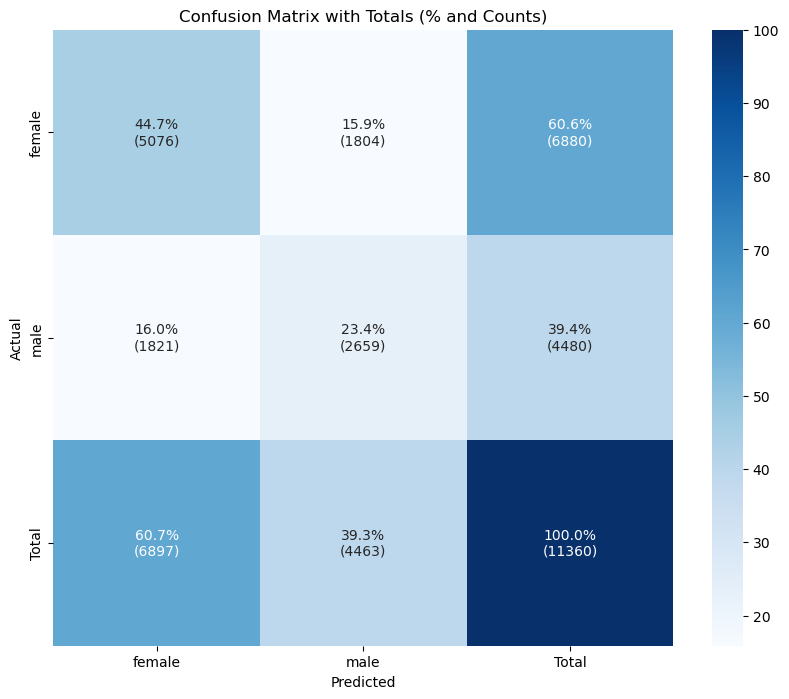

              precision    recall  f1-score   support

      female       0.74      0.74      0.74      6880
        male       0.60      0.59      0.59      4480

    accuracy                           0.68     11360
   macro avg       0.67      0.67      0.67     11360
weighted avg       0.68      0.68      0.68     11360

Accuracy: 0.6809


In [125]:
# confusion matrix patch level
grouped_res = res_df[res_df['train']==0]
true_values = grouped_res['grouped_true']
pred_values = grouped_res['y_pred']
prob_values = grouped_res['y_prob']
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Sample confusion matrix
labels = ['female', 'male']
conf = confusion_matrix(true_values, pred_values)

# Compute row and column totals
row_sums = conf.sum(axis=1, keepdims=True)
col_sums = conf.sum(axis=0, keepdims=True)
total = conf.sum()

# Build extended matrix with totals
conf_ext = np.vstack([conf, col_sums])             # Add totals row
conf_ext = np.hstack([conf_ext, np.append(row_sums, total).reshape(-1, 1)])  # Add totals column

# Convert to percentages
conf_ext_percent = conf_ext / total * 100

# Create labels for display (percentages + raw counts)
annot = np.empty_like(conf_ext).astype(str)
for i in range(conf_ext.shape[0]):
    for j in range(conf_ext.shape[1]):
        count = conf_ext[i, j]
        percent = conf_ext_percent[i, j]
        annot[i, j] = f'{percent:.1f}%\n({int(count)})'

# Define labels with "Total"
xticks = labels + ['Total']
yticks = labels + ['Total']

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(conf_ext_percent, annot=annot, fmt='', cmap='Blues', xticklabels=xticks, yticklabels=yticks)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix with Totals (% and Counts)")
plt.show()

# classification report
from sklearn.metrics import classification_report
print(classification_report(true_values, pred_values, target_names=labels))
# accuracy score
accuracy = accuracy_score(true_values, pred_values)
print(f'Accuracy: {accuracy:.4f}')
#precision = TP/(TP + FP)
#recall = TP/(TP + FN)

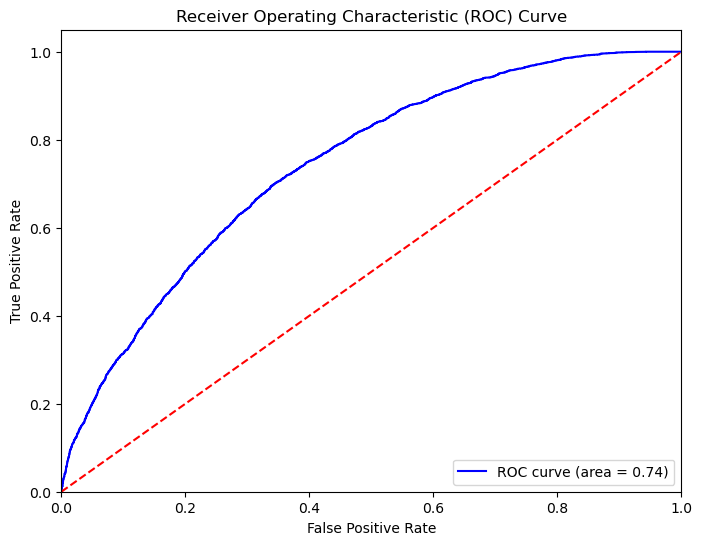

In [124]:
# ROC curve and AUC
from sklearn.metrics import roc_curve, auc
true_values = res_df[res_df['train']==0]['male']
prob_values = res_df[res_df['train']==0]['y_prob']
fpr, tpr, thresholds = roc_curve(true_values, prob_values)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()
#TPR=Recall=TP/(TP + FN)
#FPR=FP/(FP + TN)

## calibration

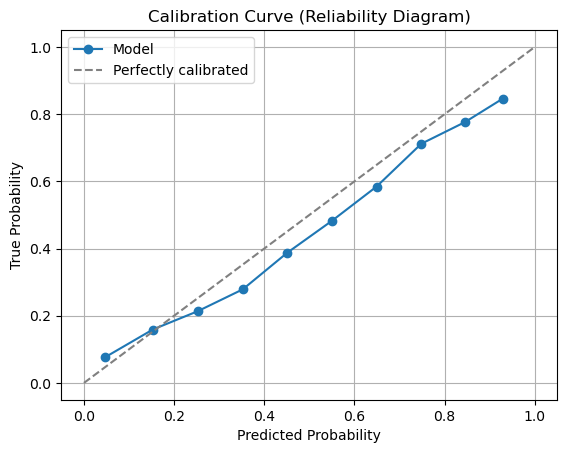

Brier Score (Uncalibrated): 0.20102634173883488


In [85]:
from sklearn.calibration import calibration_curve
true_values = res_df[res_df['train']==0]['male']
prob_values = res_df[res_df['train']==0]['y_prob']
# Get calibration data
prob_true, prob_pred = calibration_curve(true_values, prob_values, n_bins=10)

# Plot
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.xlabel('Predicted Probability')
plt.ylabel('True Probability')
plt.title('Calibration Curve (Reliability Diagram)')
plt.legend()
plt.grid()
plt.show()

from sklearn.metrics import brier_score_loss
print("Brier Score (Uncalibrated):", brier_score_loss(true_values, prob_values))

In [104]:
from sklearn.isotonic import IsotonicRegression

iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(prob_values,true_values)
calibrated_probs = iso.predict(prob_values)

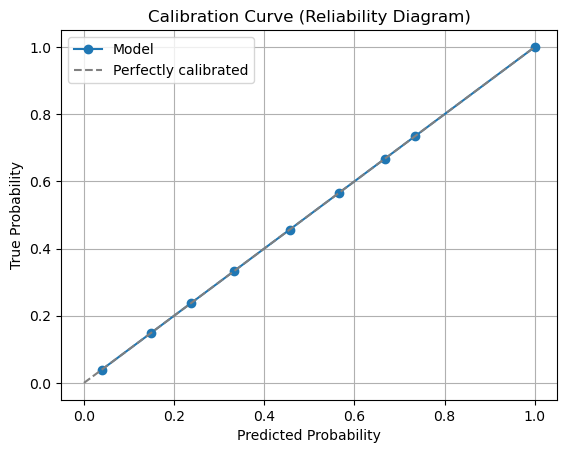

Brier Score (Uncalibrated): 0.18158718075670197


In [ ]:
# Get calibration data
prob_true, prob_pred = calibration_curve(true_values, calibrated_probs, n_bins=10)

# Plot
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.xlabel('Predicted Probability')
plt.ylabel('True Probability')
plt.title('Calibration Curve (Reliability Diagram)')
plt.legend()
plt.grid()
plt.show()

print("Brier Score (Uncalibrated):", brier_score_loss(true_values, calibrated_probs))


In [106]:
calibrated_pred = (calibrated_probs >= 0.5).astype(int)
acc = accuracy_score(true_values, calibrated_pred)

print(f"Accuracy (calibrated): {acc:.4f}")

Accuracy (calibrated): 0.7122


## select instances

In [107]:
selected = evaluation_utils.select_instances(res_df, selected_metric)

base_dir=source_path + f'/outputs/online_deep_feature_extraction/{selected_FE}/representation_extraction/'
if head_type == 'sklearn':
    search_dir = base_dir+f'sklearn_model_trained_on_rep/{selected_classification_head}/'
else:
    search_dir = base_dir+f'torch_model_trained_on_rep/{selected_classification_head}/'
selected.to_csv(search_dir+f'selected_instances_{selected_metric}.csv', index=False)
file_IO.save_args(args,search_dir)  # Save the arguments to a file

Number of unique groups for majority_vote: 12
Number of unique groups for weighted_vote: 11
Number of unique groups for most_probable: 12
['weighted_vote_sure', 'weighted_vote_unsure', 'weighted_vote_ok', 'grouped_true']


,weighted_vote_sure,weighted_vote_unsure,weighted_vote_ok,grouped_true
page,,,,
16,0,0,0,0
282,0,0,0,1
221,0,0,1,0
75,0,0,1,1
238,0,1,0,0
153,0,1,0,1
17,0,1,1,0
11,0,1,1,1
18,1,0,0,0


# reload

In [2]:
def reload_modules():
    import importlib
    import utils.data_loading as data_loading
    import utils.visualization as visualization
    import utils.dataframes as dataframes
    import utils.utils_transforms as u_transforms
    import utils.training_utils as training_utils
    import utils.model_utils as model_utils
    import utils.file_IO as file_IO
    import utils.vit_rollout_mod as vit_rollout_mod
    import utils.evaluation_utils as evaluation_utils
    import utils.script_launching as script_launching
    
    importlib.reload(file_IO)
    importlib.reload(data_loading)
    importlib.reload(visualization)
    importlib.reload(dataframes)
    importlib.reload(u_transforms)
    importlib.reload(model_utils)
    importlib.reload(training_utils)
    importlib.reload(vit_rollout_mod)
    importlib.reload(evaluation_utils)
    importlib.reload(script_launching)

    return data_loading, visualization, dataframes, u_transforms, training_utils, model_utils, file_IO, vit_rollout_mod, evaluation_utils, script_launching
data_loading, visualization, dataframes, u_transforms, training_utils, model_utils, file_IO, vit_rollout_mod, evaluation_utils, script_launching = reload_modules()